<a href="https://colab.research.google.com/github/AmitTiwari-cmd/deep-learning-journey/blob/main/mnist_digit_classification_ann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [4]:
X_train[90]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,  25, 214, 225,  90,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   7, 145, 212, 253, 253,  60,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0, 106, 253, 253, 246, 188,  23,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         45, 164, 254, 253, 223, 108,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24,
        236, 253, 252, 124,  28,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 100, 217,
        253, 218, 116,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 158, 175, 225,
        253,  92,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 217, 241, 248,
        114,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  21, 201, 253, 253, 114,
          3,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 107, 253, 253, 213,  19,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 170, 254, 254, 169,   0,
          0,   0,   0,   0,   2,  13, 100, 133,  89,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 210, 253, 253, 100,   0,
          0,   0,  19,  76, 116, 253, 253, 253, 176,   4,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  41, 222, 253, 208,  18,   0,
          0,  93, 209, 232, 217, 224, 253, 253, 241,  31,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 157, 253, 253, 229,  32,   0,
        154, 250, 246,  36,   0,  49, 253, 253, 168,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 128, 253, 253, 253, 195, 125,
        247, 166,  69,   0,   0,  37, 236, 253, 168,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  37, 253, 253, 253, 253, 253,
        135,  32,   0,   7, 130,  73, 202, 253, 133,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   7, 185, 253, 253, 253, 253,
         64,   0,  10, 210, 253, 253, 253, 153,   9,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  66, 253, 253, 253, 253,
        238, 218, 221, 253, 253, 235, 156,  37,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   5, 111, 228, 253, 253,
        253, 253, 254, 253, 168,  19,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   9, 110, 178,
        253, 253, 249,  63,   5,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

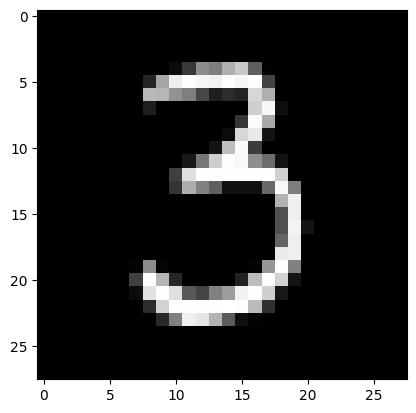

In [5]:
plt.imshow(X_train[50],cmap = "gray")

In [6]:
X_train = X_train/255
X_test = X_test/255
y_train = tf.keras.utils.to_categorical(y_train,10)
y_test = tf.keras.utils.to_categorical (y_test,10)

In [7]:
model = Sequential([
    Flatten(input_shape = (28,28)),
    Dense(128, activation = "relu"),
    Dense(64,activation = "relu"),
    Dense(10,activation = "softmax")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.compile(optimizer = "adam", loss = "categorical_crossentropy",metrics = ["accuracy"])

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs = 10,
    validation_data = (X_test,y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9273 - loss: 0.2463 - val_accuracy: 0.9641 - val_loss: 0.1168
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9683 - loss: 0.1030 - val_accuracy: 0.9710 - val_loss: 0.0926
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9773 - loss: 0.0725 - val_accuracy: 0.9671 - val_loss: 0.1074
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9820 - loss: 0.0557 - val_accuracy: 0.9765 - val_loss: 0.0766
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9865 - loss: 0.0424 - val_accuracy: 0.9788 - val_loss: 0.0749
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9882 - loss: 0.0365 - val_accuracy: 0.9773 - val_loss: 0.0840
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9904 - loss: 0.0290 - val_accuracy: 0.9733 - val_loss: 0.0926
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9914 - loss: 0.0256 -

In [10]:
history.history["val_accuracy"]

[0.9641000032424927,
 0.9710000157356262,
 0.9671000242233276,
 0.9764999747276306,
 0.9787999987602234,
 0.9772999882698059,
 0.9732999801635742,
 0.9797999858856201,
 0.9793000221252441,
 0.9763000011444092]

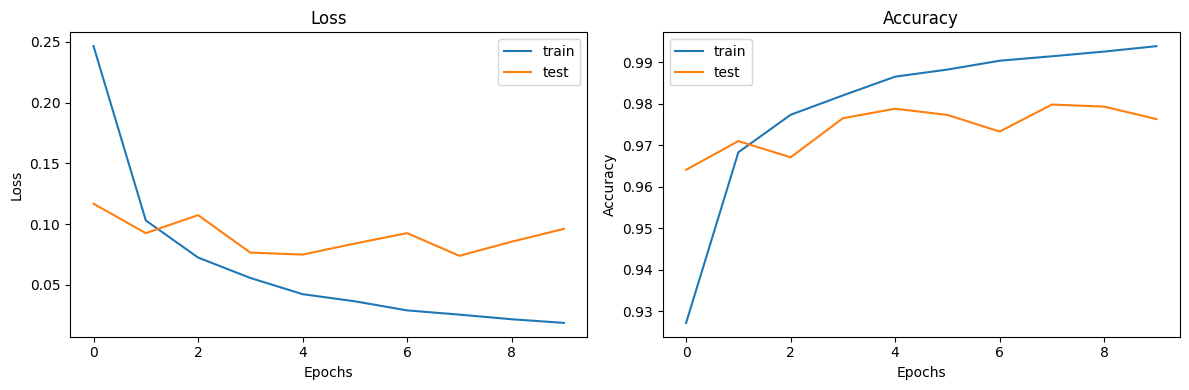

In [11]:
fig, axes = plt.subplots(1,2, figsize = (12,4))
axes[0].plot(history.history["loss"],label = "train")
axes[0].plot(history.history["val_loss"],label = "test")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[1].plot(history.history["accuracy"],label = "train")
axes[1].plot(history.history["val_accuracy"],label = "test")
axes[1].set_title("Accuracy")
axes[1].legend()
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")
plt.tight_layout()
plt.show()

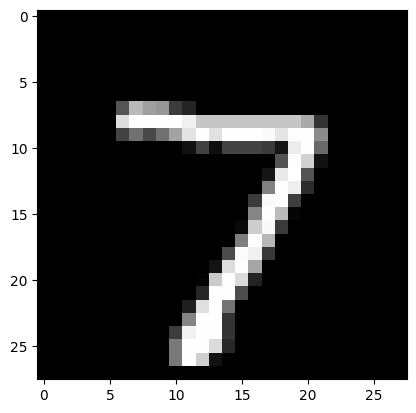

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted Value : 7


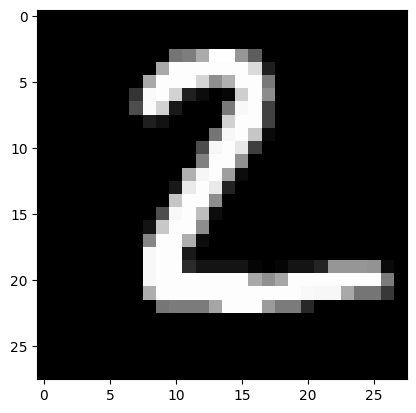

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted Value : 2


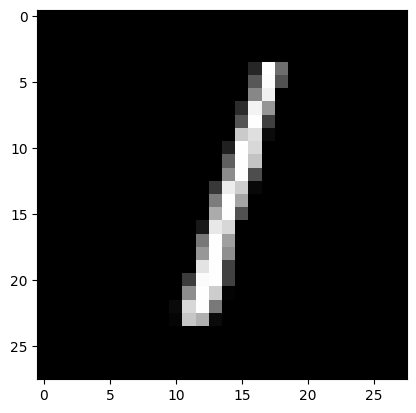

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted Value : 1


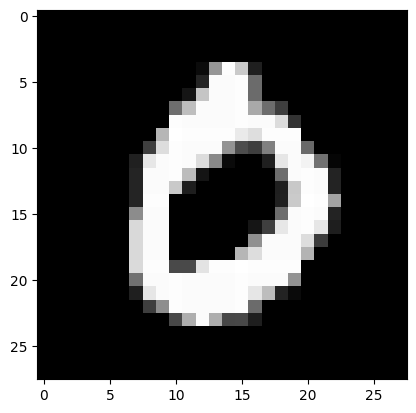

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted Value : 0


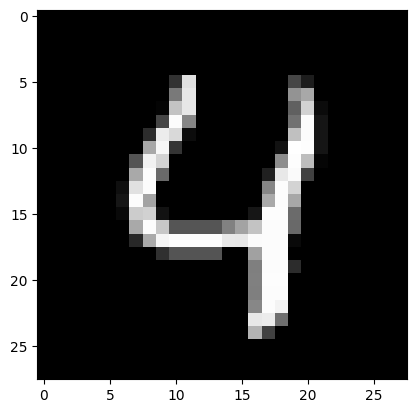

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted Value : 4


In [25]:
for i in range(5):
    plt.imshow(X_test[i],cmap = "gray")
    plt.show()
    print(f"Predicted Value : {np.argmax(model.predict(X_test[i].reshape(1,28,28)))}")

In [69]:
def various_architectures(neurons):
  model = Sequential([
    Flatten(input_shape = (28,28)),
    Dense(neurons, activation = "relu"),
    Dense(neurons//2,activation = "relu"),
    Dense(10,activation = "softmax")
  ])
  model.compile(optimizer = "adam", loss = "categorical_crossentropy",metrics = ["accuracy"])
  history = model.fit(
    X_train,
    y_train,
    epochs = 3,
    validation_data = (X_test,y_test)
  )
  print(type(history.history))
  return history.history

In [72]:
def plot_accuracy(neurons):

  for neuron in neurons:
      history = various_architectures(neuron)
      plt.plot(history["accuracy"],label = f"train {neuron}")
      plt.plot(history["val_accuracy"],label = f"validation {neuron}")
      plt.legend()
  plt.title(f"Accuracy for neurons")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.tight_layout()
  plt.show()


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9121 - loss: 0.3056 - val_accuracy: 0.9510 - val_loss: 0.1646
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9591 - loss: 0.1400 - val_accuracy: 0.9609 - val_loss: 0.1287
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9688 - loss: 0.1056 - val_accuracy: 0.9651 - val_loss: 0.1162
<class 'dict'>
Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8911 - loss: 0.3765 - val_accuracy: 0.9277 - val_loss: 0.2389
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9431 - loss: 0.1977 - val_accuracy: 0.9519 - val_loss: 0.1659
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9543 - loss: 0.1525 - val_accuracy: 0.9567 - val_loss: 0.1462
<class 'dict'>


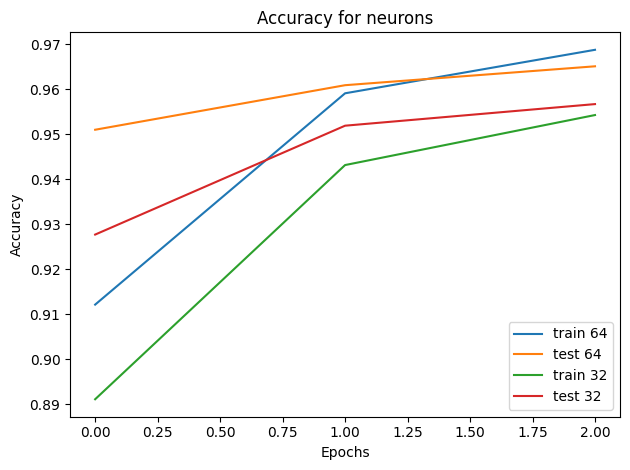

In [74]:
neurons = [64,32]

plot_accuracy(neurons)
